In [ ]:
from ema_forecast_control.utils import path_utils, model_catalogue

project_name = f'v3_MRT3_every_day_best_latest_all'
test_data_dir = path_utils.get_data_dir('AI4U_sample3')

labels = ['mood','disappointed','scared','worry',
    'down','sad','confidence','stress','lonely',
    'energetic','concentration','resilience','tired',
    'satisfied', 'relaxed']
input_labels = ['CE', 'CYB', 'CSP', 'BB', 'CC', 'EW', 'JJM', 'PDL']

save_as = f'AI4U/perturbation_analysis_emis/{project_name}.png'

### PLRNN

Calculate cumulative impulse responses for inputs targeted at single nodes

In [ ]:
import sys
sys.path.append('..')
import os
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control.utils.backwards_compatibility import determine_model_class
from ema_forecast_control.utils import network_utils
from ema_forecast_control.plrnn.plrnn_model import PLRNN

T = 7

errors_loading_model = 0
obs_features = path_utils.get_project_arg(project_name, 'obs_features', from_trained_models=True)
models = model_catalogue.ModelCatalogue(project_name, force_new_catalogue=True)

plrnn_cir = []
for p, df in path_utils.zip_participants_data(test_data_dir):
    model_dirs = models.get_latest_model_dirs(p, timestep=1000)
    if len(model_dirs) == 0:
        continue
    ensemble_cir = []
    for model_dir in model_dirs:
        args = path_utils.load_args(model_dir)
        if determine_model_class(args) != PLRNN:
            raise ValueError('Model is not PLRNN')
        model = PLRNN()
        model.init_from_model_path(model_dir)
        try:
            Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
        except:
            errors_loading_model += 1
            continue
        x = tc.tensor(df[obs_features].to_numpy()).float()
        network = network_utils.get_network_matrix(model, x, Gamma=Gamma).nanmean(0)
        C = model.get_parameters()['C']
        B = model.get_observation_model()
        
        model_cir = []
        x0 = tc.cat((tc.eye(x.shape[1]).float(), tc.zeros(x.shape[1]).float().unsqueeze(0)), 0)
        for i in range(C.shape[1]):
            perturbation = tc.zeros(C.shape[1]).float()
            perturbation[i] = 1
            subject_cir = network_utils.impulse_response(model, perturbation, T, cumulative=True, relative=True, x0=x0,
                                                                Gamma=Gamma).mean(axis=0)
            model_cir.append(subject_cir)
        model_cir = tc.stack(model_cir, dim=0)
        ensemble_cir.append(model_cir)
    if len(ensemble_cir) == 0:
        continue
    ensemble_cir = tc.stack(ensemble_cir, dim=0).mean(0)
    plrnn_cir.append(ensemble_cir)

plrnn_cir = tc.stack(plrnn_cir, dim=0)

# dims of mrt_cir: (mrt, subject, perturb_node, feature); dims of mrt_out_centrality: (mrt, subject, perturb_node)

Plot cumulative impulse response of each EMI

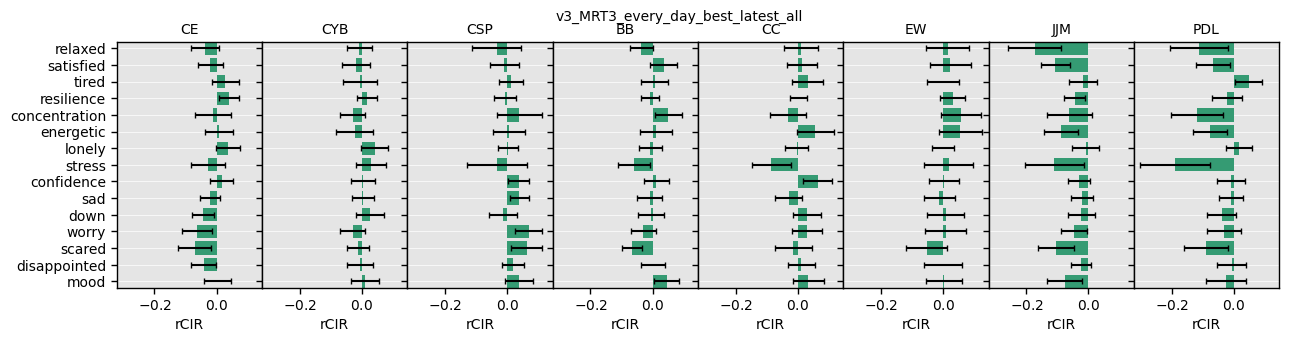

In [ ]:
from scipy import stats
from ema_forecast_control.plotting.plotting_styles import PaperStyle

with PaperStyle():

    fig, axes = plt.subplots(1, 8, figsize=(15, 3.2), sharey=True, sharex=True)
    z_cir = plrnn_cir

    for i, (emi, ax) in enumerate(zip(range(z_cir.shape[1]), axes.flatten())):

        emi_cir = z_cir[:, emi]            
        ax.barh(tc.arange(z_cir.shape[2]), emi_cir.mean(0), xerr=stats.sem(emi_cir, axis=0), color='#359B73')
        ax.set_yticks(range(z_cir.shape[2]), labels=labels)
        ax.set_title(input_labels[emi])
        ax.set(xlabel='rCIR')
        
    fig.suptitle(project_name)
    # fig.tight_layout()
    plt.subplots_adjust(wspace=0)
    if save_as is not None:
        plt.savefig(path_utils.join_base_path('results', save_as), dpi=300)
    plt.show()
